# Reproducing Arabidopsis seed counting with the ShiuLab frozen Faster R-CNN model

**Paper:** *High throughput measurement of *Arabidopsis thaliana* fitness traits using transfer learning* (bioRxiv 2021.07.01.450758 v2; published as *New Phytologist*, doi:10.1111/nph.18056).
**Author code & models:** [ShiuLab/Manuscript_Code](https://github.com/ShiuLab/Manuscript_Code) `2022_Arabidopsis_seed_and_fruit_count`, pinned commit `7478aa50419b18b80b682ab00c5e353d89430719` (GPL-3.0 license).

**Scope (partial demonstration):** apply the authors' released **frozen Faster R-CNN seed-counting model** (`Seed_counting_model/graph_train/frozen_inference_graph.pb`) to author-provided annotated seed-scan tiles and reproduce their counting rule: **seed count = number of detections with score ≥ 0.5** (see author script `Scripts_for_Faster_R-CNN/06_detect.py`). We compare predicted counts with the authors' own XML ground-truth annotations and draw the detection boxes. This is a one/few-example demonstration; it does **not** verify the paper's dataset-level accuracy (F1 = 0.992, seed-count r² = 0.9996 over 50 test images).

**重要な注記 (AI-assisted adaptation):** The authors used TensorFlow 1.13.2 with Python ≤ 3.7. This notebook is an **AI-assisted compatibility adaptation**: the *authors' own frozen model weights and counting logic* are used unchanged, but the legacy frozen graph is loaded through `tensorflow.compat.v1` inside modern TensorFlow 2 on Colab (Python 3.11/3.12). The authors did not provide this Colab implementation; the executed example and checks below were validated, but untested behavior is not guaranteed. Scientific operations, weights, thresholds and units are the authors'.

**実行範囲（部分再現）:** 論文の著者らが公開した凍結済み Faster R-CNN モデルを、著者提供の注釈付きシード画像に適用し、スコア ≥ 0.5 の検出数を数える著者のカウント手順を再現します。著者の XML アノテーションと比較します。データセット全体の精度検証ではありません。

**Runtime:** CPU is sufficient (single-image Faster R-CNN inference). No GPU needed. Expected total time ≈ 5–10 min, ≈ 55 MB downloads. **Runtime → Change runtime type → CPU** (or leave default). Then *Runtime → Run all*.


## 1. Environment check

We first check the Colab Python and TensorFlow versions. The notebook relies on `tensorflow.compat.v1`, which is part of any TensorFlow 2.x install — no special legacy environment is required.

**説明:** Colab の Python / TensorFlow バージョンを確認します。レガシー環境の構築は不要です。

In [ ]:
import sys, tensorflow as tf
print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
assert tf.__version__.startswith("2."), "This notebook expects TensorFlow 2.x (compat.v1 layer)."


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow: 2.20.0


## 2. Download the authors' model and annotated sample images (provenance-pinned)

All inputs are fetched from the authors' public GitHub repository at the **pinned commit** `7478aa50419b18b80b682ab00c5e353d89430719` (raw.githubusercontent.com). We download:

- `Seed_counting_model/graph_train/frozen_inference_graph.pb` — the released seed model (~52 MB);
- two annotated seed-scan tiles from `Seed_annotation_for_Faster_R-CNN/` (JPEG input + Pascal-VOC XML ground truth), used by the authors to document model-assisted annotation;
- one high-density tile from `seed_density/` with the authors' own saved detection CSV (`scan21_111918022.jpg_0_2.jpg.csv`), for an extra reference comparison.

Each download is checked against the file size recorded in the pinned repository tree.

**説明:** 著者の公開リポジトリ（コミット固定）から凍結済みモデルと注釈付きサンプル画像・XML・著者検出CSVをダウンロードし、サイズを検証します。

In [ ]:
import urllib.request, os

COMMIT = "7478aa50419b18b80b682ab00c5e353d89430719"
BASE = "https://raw.githubusercontent.com/ShiuLab/Manuscript_Code/7478aa50419b18b80b682ab00c5e353d89430719/2022_Arabidopsis_seed_and_fruit_count"
# (remote_path, expected_bytes) sizes from the pinned GitHub tree listing (2026-10-05)
FILES = [
    ("Seed_counting_model/graph_train/frozen_inference_graph.pb", 52124705),
    ("Seed_annotation_for_Faster_R-CNN/scan15_110918016.jpg_2_2.jpg", 295176),
    ("Seed_annotation_for_Faster_R-CNN/scan15_110918016.jpg_2_2.xml", 85347),
    ("seed_density/scan21_111918022.jpg_0_2.jpg", 453147),
    ("Seed_annotation_for_Faster_R-CNN/scan21_111918022.jpg_0_2.xml", 252428),
    ("seed_density/scan21_111918022.jpg_0_2.jpg.csv", 69934),
]
os.makedirs("/content/shiu_seed", exist_ok=True)
for rel, expected in FILES:
    dest = "/content/shiu_seed/" + os.path.basename(rel)
    if not (os.path.exists(dest) and os.path.getsize(dest) == expected):
        urllib.request.urlretrieve(f"{BASE}/{rel}", dest)
    got = os.path.getsize(dest)
    assert got == expected, f"size mismatch for {rel}: {got} != {expected}"
    print(f"OK {expected:>9} bytes  {rel}")


OK  52124705 bytes  Seed_counting_model/graph_train/frozen_inference_graph.pb
OK    295176 bytes  Seed_annotation_for_Faster_R-CNN/scan15_110918016.jpg_2_2.jpg


OK     85347 bytes  Seed_annotation_for_Faster_R-CNN/scan15_110918016.jpg_2_2.xml


OK    453147 bytes  seed_density/scan21_111918022.jpg_0_2.jpg
OK    252428 bytes  Seed_annotation_for_Faster_R-CNN/scan21_111918022.jpg_0_2.xml


OK     69934 bytes  seed_density/scan21_111918022.jpg_0_2.jpg.csv


## 3. Input preview — what the model sees

The samples are 1200-dpi scans of single plate lids holding Arabidopsis seeds (one lid per image), the same image class the authors' pipeline expects. We show both test tiles before any model is applied.

**説明:** モデルに入力するシード画像（60 mm プレート蓋の 1200 dpi スキャン、1 蓋/画像）を表示します。

scan15_110918016.jpg_2_2 (2900, 2900) RGB
scan21_111918022.jpg_0_2 (2900, 2900) RGB


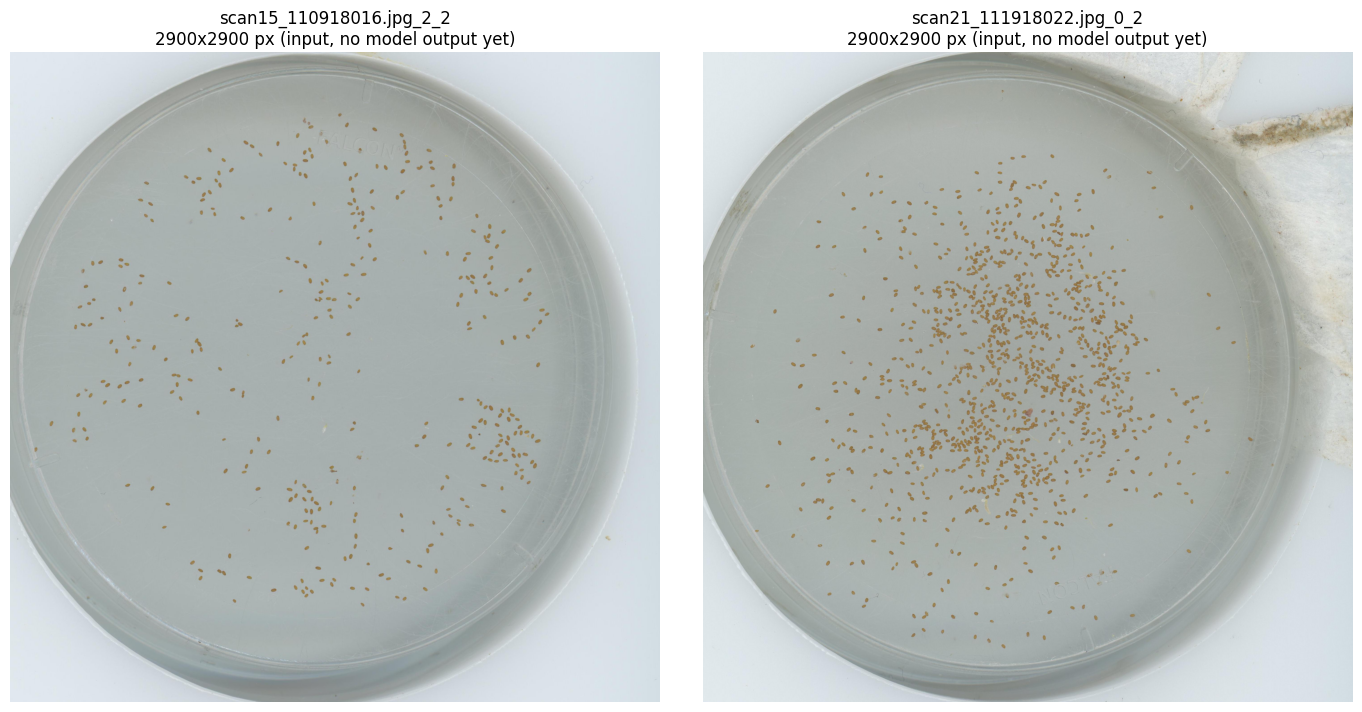

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

samples = {
    "scan15_110918016.jpg_2_2": "/content/shiu_seed/scan15_110918016.jpg_2_2.jpg",
    "scan21_111918022.jpg_0_2": "/content/shiu_seed/scan21_111918022.jpg_0_2.jpg",
}
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (name, path) in zip(axes, samples.items()):
    im = Image.open(path)
    print(name, im.size, im.mode)
    ax.imshow(im)
    ax.set_title(f"{name}\n{im.size[0]}x{im.size[1]} px (input, no model output yet)")
    ax.axis("off")
plt.tight_layout(); plt.show()


## 4. Load the authors' frozen inference graph (legacy TF1 format via compat.v1)

The authors' `06_detect.py` loads `frozen_inference_graph.pb`, feeds a uint8 HWC image to `image_tensor:0`, and reads `detection_scores:0` / `detection_boxes:0`. We keep exactly those tensor names and counting rule; only the loader is adapted to `tf.compat.v1` so the TF1 graph runs on the modern Colab runtime.

**説明:** 著者のコードと同じテンソル名（`image_tensor:0`, `detection_scores:0`, `detection_boxes:0`）で TF1 形式の凍結グラフを `tf.compat.v1` 経由で読み込みます。

In [ ]:
import numpy as np
import tensorflow.compat.v1 as tfc

PATH_TO_CKPT = "/content/shiu_seed/frozen_inference_graph.pb"

detection_graph = tfc.Graph()
with detection_graph.as_default():
    od_graph_def = tfc.GraphDef()
    with tfc.gfile.GFile(PATH_TO_CKPT, "rb") as fid:
        od_graph_def.ParseFromString(fid.read())
        tfc.import_graph_def(od_graph_def, name="")
print("Frozen graph loaded into a tf.compat.v1 Graph.")


Frozen graph loaded into a tf.compat.v1 Graph.


## 5. Run seed detection and apply the authors' counting rule (score ≥ 0.5)

This mirrors the inference loop of `06_detect.py`: each uint8 image is expanded to a batch of 1, the session returns detection scores/boxes, and the count is the number of scores ≥ 0.5. On CPU each image takes a few seconds to a few minutes.

**説明:** `06_detect.py` と同じ推論ループ（score ≥ 0.5 の検出数をカウント）を実行します。CPU で1枚あたり数秒〜数分です。

In [ ]:
def run_inference(image_np):
    """Mirror of 06_detect.py run_inference_for_single_image, via tf.compat.v1."""
    with detection_graph.as_default():
        with tfc.Session() as sess:
            scores_t = detection_graph.get_tensor_by_name("detection_scores:0")
            boxes_t = detection_graph.get_tensor_by_name("detection_boxes:0")
            image_t = detection_graph.get_tensor_by_name("image_tensor:0")
            out = sess.run({"detection_scores": scores_t, "detection_boxes": boxes_t},
                           feed_dict={image_t: np.expand_dims(image_np, 0)})
    return out["detection_scores"][0], out["detection_boxes"][0]

def load_image_into_numpy_array(image):
    (im_width, im_height) = image.size
    return np.array(image.getdata()).reshape((im_height, im_width, 3)).astype(np.uint8)

images = {}
for name, path in samples.items():
    img = Image.open(path)
    image_np = load_image_into_numpy_array(img)
    scores, boxes = run_inference(image_np)
    count = int((scores >= 0.5).sum())          # authors' counting rule
    images[name] = {"image_np": image_np, "scores": scores, "boxes": boxes, "count": count}
    print(f"{name}: model seed count (score>=0.5) = {count}")


scan15_110918016.jpg_2_2: model seed count (score>=0.5) = 374


scan21_111918022.jpg_0_2: model seed count (score>=0.5) = 1101


## 6. Ground truth from the authors' XML annotations and comparison table

Each sample has a Pascal-VOC `.xml` annotation (one `object` per annotated seed) produced by the authors' labeling. We parse the object counts and compare them with the model counts, and also load the authors' own saved detection CSV for the density sample (their `06_detect_save_image_results.py` output format: rows of detections).

**説明:** 著者の XML アノテーション（シード1個 = object 1個）を解析し、モデルのカウントと比較します。密度サンプルには著者自身の検出CSVも読み込みます。

In [ ]:
import xml.etree.ElementTree as ET
import csv

def xml_seed_count(path):
    root = ET.parse(path).getroot()
    return sum(1 for obj in root.iter("object"))

rows = []
for name, path in samples.items():
    xml_path = "/content/shiu_seed/" + (os.path.basename(path)[:-4] + ".xml")
    gt = xml_seed_count(xml_path)
    rows.append([name, gt, images[name]["count"], images[name]["count"] - gt])

# Authors' own saved detections for the density sample. The file schema is not
# documented, so inspect it first and only count when a score column is evident.
csv_path = "/content/shiu_seed/scan21_111918022.jpg_0_2.jpg.csv"
with open(csv_path) as fh:
    raw = [next(fh) for _ in range(4)]
print("Raw first lines of the author-saved CSV:")
for line in raw: print("  ", line.rstrip())
first_fields = next(csv.reader([raw[0]]))
header_like = any(not f.replace(".", "").isdigit() for f in first_fields)
score_col = None
if header_like:
    cols = [c.strip().lower() for c in first_fields]
    score_col = next((i for i, c in enumerate(cols) if "score" in c), None)
if score_col is not None:
    with open(csv_path) as fh:
        r = csv.reader(fh); next(r)
        author_csv_scores = [float(row[score_col]) for row in r if row]
    author_csv_count = sum(1 for s in author_csv_scores if s >= 0.5)
    print(f"Author saved-CSV detections with score>=0.5 for {rows[1][0]}: {author_csv_count} (score column: '{first_fields[score_col]}')")
else:
    print("No clear score column in the author CSV; comparison limited to XML ground truth.")

print(f"{'sample':32} {'XML ground truth':>16} {'model count':>12} {'diff':>6}")
for name, gt, mc, diff in rows:
    print(f"{name:32} {gt:16d} {mc:12d} {diff:6d}")


Raw first lines of the author-saved CSV:
   scan21_111918022.jpg_0_2.jpg,2900,2900,seed,1117,1113,1143,1135
   scan21_111918022.jpg_0_2.jpg,2900,2900,seed,1315,525,1340,547
   scan21_111918022.jpg_0_2.jpg,2900,2900,seed,1219,1149,1243,1175
   scan21_111918022.jpg_0_2.jpg,2900,2900,seed,1280,1346,1304,1368
No clear score column in the author CSV; comparison limited to XML ground truth.
sample                           XML ground truth  model count   diff
scan15_110918016.jpg_2_2                      373          374      1
scan21_111918022.jpg_0_2                     1104         1101     -3


## 7. Visualization — model detections on the input images

We draw the model's score ≥ 0.5 boxes (model predictions) and, separately, the XML ground-truth boxes (reference annotations), so predictions and reference can be compared on the original input. The figures are saved as PNG outputs of this notebook.

**説明:** モデルの検出ボックス（予測）と XML アノテーション（参照正解）を元画像上に描画して比較します。図は PNG 出力として保存されます。

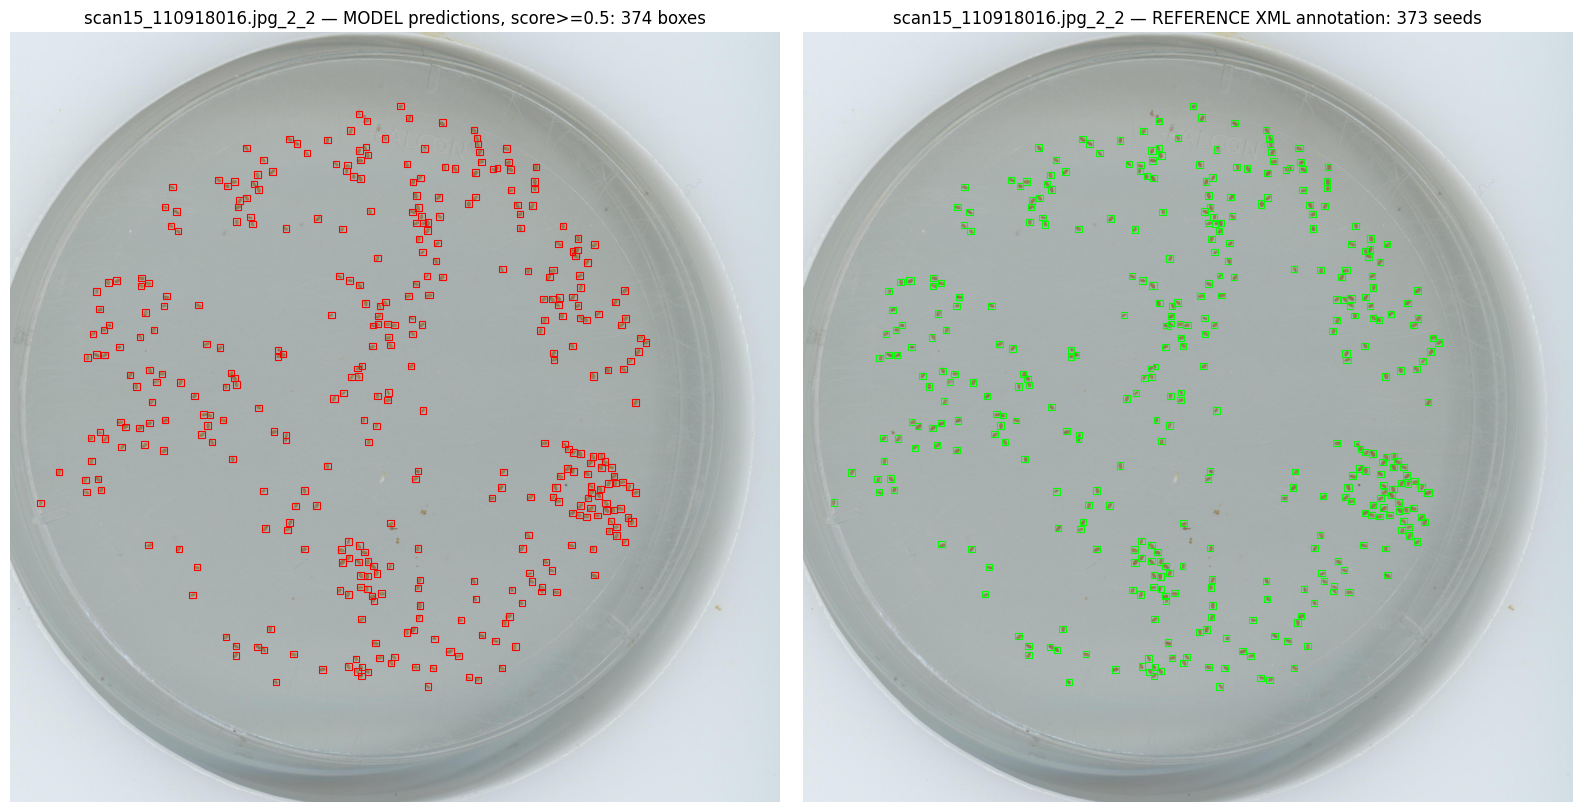

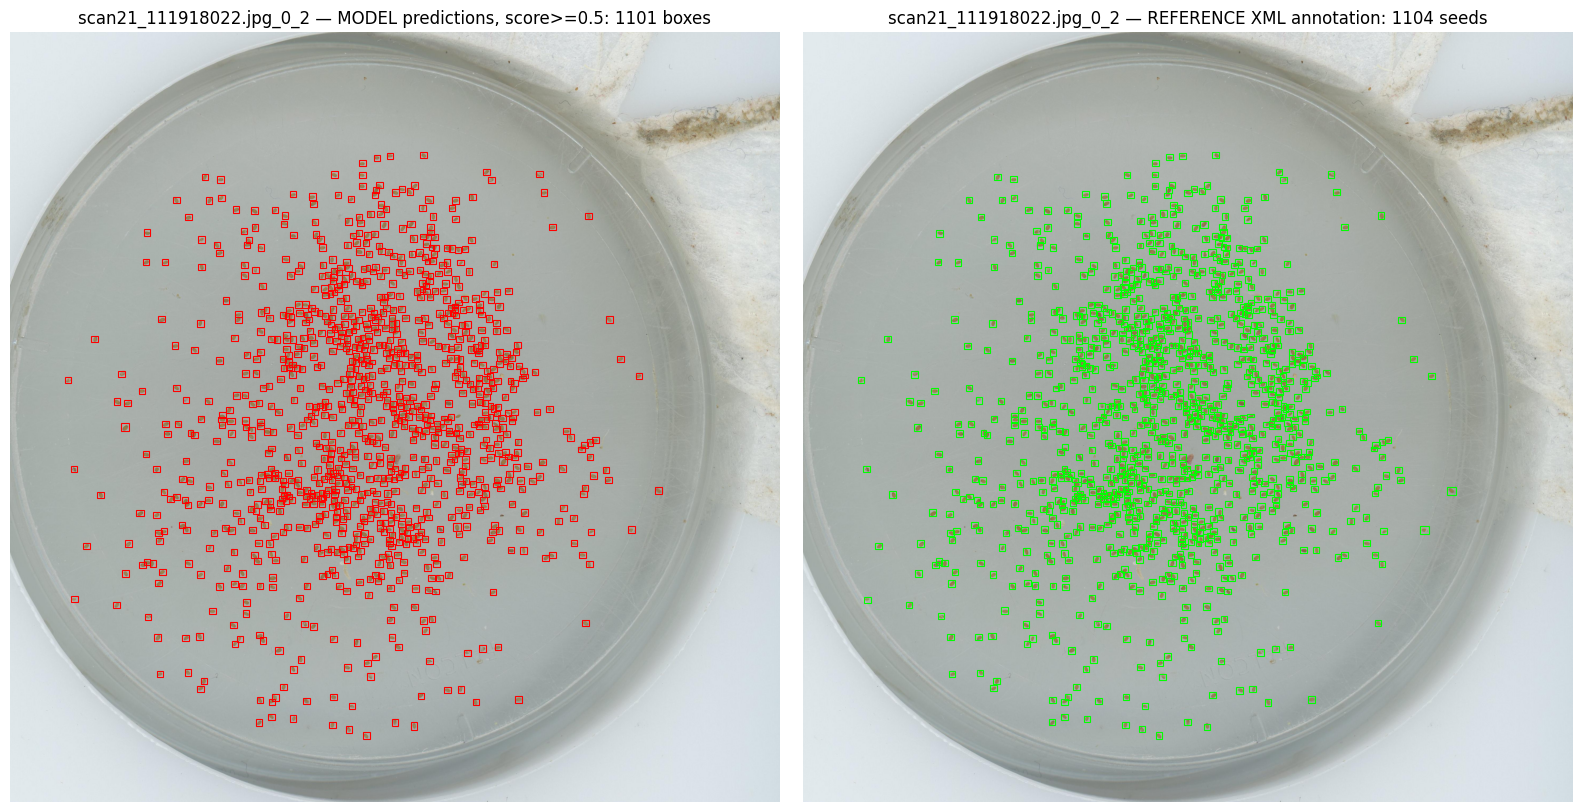

In [ ]:
import matplotlib.patches as mpatches

def draw(ax, image_np, boxes, color, label):
    h, w = image_np.shape[:2]
    for ymin, xmin, ymax, xmax in boxes:
        ax.add_patch(mpatches.Rectangle((xmin*w, ymin*h), (xmax-xmin)*w, (ymax-ymin)*h,
                     fill=False, edgecolor=color, linewidth=0.8))
    ax.imshow(image_np); ax.axis("off"); ax.set_title(label)

def xml_boxes(path):
    root = ET.parse(path).getroot()
    out = []
    for obj in root.iter("object"):
        b = obj.find("bndbox")
        W = int(root.find("size/width").text); H = int(root.find("size/height").text)
        out.append((int(b.find("ymin").text)/H, int(b.find("xmin").text)/W,
                    int(b.find("ymax").text)/H, int(b.find("xmax").text)/W))
    return out

for name, path in samples.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    img = images[name]["image_np"]
    keep = images[name]["scores"] >= 0.5
    draw(axes[0], img, images[name]["boxes"][:keep.sum()], "red",
         f"{name} — MODEL predictions, score>=0.5: {keep.sum()} boxes")
    draw(axes[1], img, xml_boxes("/content/shiu_seed/" + (os.path.basename(path)[:-4] + ".xml")),
         "lime", f"{name} — REFERENCE XML annotation: {xml_seed_count('/content/shiu_seed/' + (os.path.basename(path)[:-4] + '.xml'))} seeds")
    plt.tight_layout(); plt.show()


## 8. Export results as CSV

A small results table (sample, ground-truth count, model count, difference) is written under `/content` and also displayed, so learners can keep a machine-readable record.

**説明:** 結果表（サンプル名・正解数・モデル数・差分）を CSV として保存・表示します。

In [ ]:
import pandas as pd
df = pd.DataFrame(rows, columns=["sample", "xml_ground_truth_seeds", "model_count_score_0.5", "difference"])
df.to_csv("/content/shiu_seed/seed_count_comparison.csv", index=False)
print(df.to_string(index=False))
print("saved: /content/shiu_seed/seed_count_comparison.csv")


                  sample  xml_ground_truth_seeds  model_count_score_0.5  difference
scan15_110918016.jpg_2_2                     373                    374           1
scan21_111918022.jpg_0_2                    1104                   1101          -3
saved: /content/shiu_seed/seed_count_comparison.csv


## 9. Interpretation, scope and references

**What was verified here (observed outputs above):** the authors' released frozen seed model runs on their own sample images and its score ≥ 0.5 count is computed with their rule and compared to their own XML annotations. A single-example (or two-example) agreement — or disagreement — does **not** establish the paper's reported accuracy (F1 = 0.992, seed-count r² = 0.9996 over the 50-image test set, Modelseed 67); that would require the full test set, which is not published as individual downloadable files in the repository.

**Adaptation record:** TF1 frozen graph loaded via `tensorflow.compat.v1` on TF2 (the only change; the authors' loader used TF 1.13.2 / Python 3.7). Tensor names, dtype, counting rule (score ≥ 0.5), and input format (uint8 HWC RGB) are unchanged from `Scripts_for_Faster_R-CNN/06_detect.py`.

**Not covered by this notebook:** fruit counting, ImageJ baseline, model training, data augmentation (Modelseed 68), and mutant fitness statistics.

**References**
- Paper: bioRxiv 2021.07.01.450758 v2; *New Phytologist* doi:10.1111/nph.18056.
- Code/models: https://github.com/ShiuLab/Manuscript_Code (2022_Arabidopsis_seed_and_fruit_count), commit `7478aa50419b18b80b682ab00c5e353d89430719`, GPL-3.0.

**検証されたこと:** 著者の公開モデルを著者のサンプル画像で実行し、score ≥ 0.5 のカウント規則を著者の XML 正解と比較しました。少数例の一致は論文のデータセット全体精度の検証ではありません。変更はグラフ読み込みの TF2 互換のみで、モデル・しきい値・入力形式は著者のコードのままです。
